In [1]:
from base_model import get_model
from args_yaml import get_args_from_yaml
from utils import model_detail

In [2]:
args, ds_init = get_args_from_yaml('arg_ft.yaml')

In [3]:
model = get_model(args)

Patch size = 200
Load ckpt from ./checkpoints/labram-base.pth
Load state_dict by model_key = model
Weights of NeuralTransformer not initialized from pretrained model: ['fc_norm.weight', 'fc_norm.bias']
Weights from pretrained model not used in NeuralTransformer: ['mask_token', 'lm_head.weight', 'lm_head.bias', 'norm.weight', 'norm.bias']


In [4]:
import torch
import numpy as np
from utils import get_input_chans
device = torch.device('cuda')
bs = 64
ts = 4
ch_names = ['FP1', 'FP2', 'FPZ']
data = torch.Tensor(np.random.randn(bs, len(ch_names), ts, 200)).to(device)
data.shape

torch.Size([64, 3, 4, 200])

In [5]:
out = model.forward(data, input_chans = get_input_chans(ch_names))

[0, 1, 3, 2]


In [6]:
out.shape

torch.Size([64, 200])

In [7]:
out

tensor([[-1.1922,  0.5753, -0.2628,  ..., -0.3146, -0.9185,  0.9373],
        [-0.6683, -0.2553, -0.2514,  ..., -0.9233, -0.5698,  0.4534],
        [-0.5422,  0.1399, -0.3881,  ..., -0.7000,  0.3747,  0.5165],
        ...,
        [-0.8102, -0.5597,  0.5389,  ..., -0.8147, -0.3805,  0.9020],
        [-0.4349, -0.2232, -0.5670,  ..., -0.9172,  0.6244,  0.6548],
        [-1.2999, -0.3635, -0.2821,  ..., -0.3680, -0.3881,  0.4651]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multivariate_timeseries(
    data,
    t=None,
    y_offset=1.0,
    labels=None,
    figsize=(10, 5)
):
    """
    显示多维时序信号（按维度纵向偏移）

    Parameters
    ----------
    data : np.ndarray
        形状为 [n_time, n_dim] 的时序数据
    t : np.ndarray or None
        时间轴，形状为 [n_time]，None 时使用索引
    y_offset : float
        各维度之间的纵向偏移量
    labels : list[str] or None
        每个维度的标签
    figsize : tuple
        图像大小
    """
    data = np.asarray(data)
    assert data.ndim == 2, "data 必须是 [n_time, n_dim]"

    n_time, n_dim = data.shape

    if t is None:
        t = np.arange(n_time)

    plt.figure(figsize=figsize)

    for i in range(n_dim):
        offset = i * y_offset
        plt.plot(t, data[:, i] + offset, label=labels[i] if labels else f"dim {i}")

    plt.xlabel("Time")
    plt.ylabel("Amplitude + offset")
    plt.title("Multivariate Time Series")
    plt.grid(True, alpha=0.3)

    if labels is not None:
        plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
DATA_ROOT_DIR = '/emo-eeg'
DATASET_NAME = 'FACED_standard'
run_name = 'default_run_name'
fea_save_dir = f'{DATA_ROOT_DIR}/{DATASET_NAME}/fea'    
label_dir = f'{fea_save_dir}/label_{run_name}.npy'
label = np.load(label_dir)

array([0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)

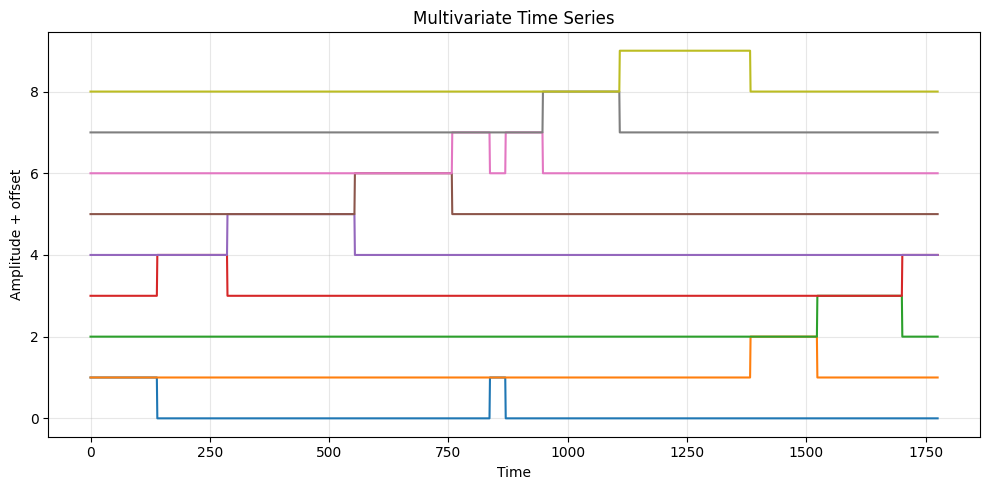

In [15]:
plot_multivariate_timeseries(label, y_offset=1)